Saving Copy of supvec .xlsx to Copy of supvec .xlsx

Dataset loaded Successfully!

  Sample ID  Soil Nitrogen (mg/kg)  Avg Rainfall (mm)  Class Label    Class
0      W001                  70.83             602.05            1  Healthy
1      W002                  75.15             556.55            1  Healthy
2      W003                  92.58             698.62            1  Healthy
3      W004                  84.47             608.76            1  Healthy
4      W005                  66.91             723.59            1  Healthy

====Results for C=0.01====
Accuracy: 1.0
COmfusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(



====Results for C=1====
Accuracy: 1.0
COmfusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21


====Results for C=100====
Accuracy: 1.0
COmfusion Matrix:
 [[ 9  0]
 [ 0 12]]
Classification Report:
               precision    recall  f1-score   support

          -1       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


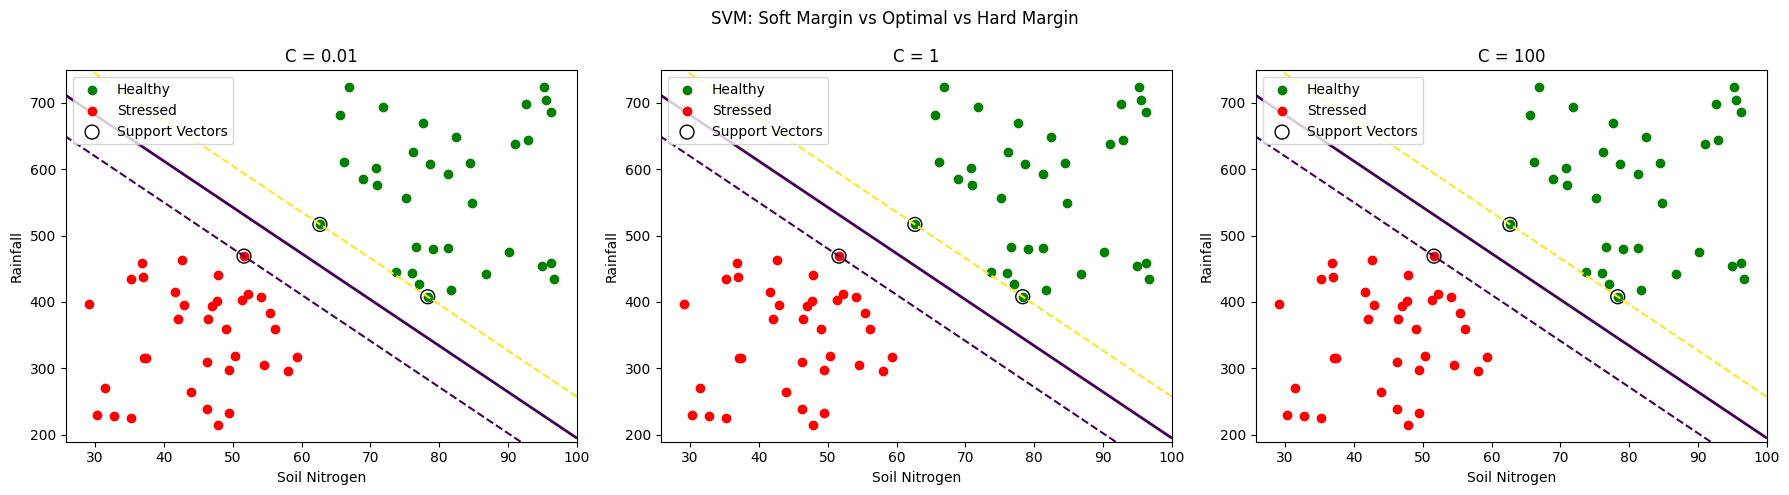

In [5]:
from google.colab import files
uploaded= files.upload()

file_name= list(uploaded.keys())[0]

import pandas as pd
import numpy as np
from sklearn import svm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

df=pd.read_excel(file_name)

print("\nDataset loaded Successfully!\n")
print(df.head())

df.columns = df.columns.str.strip()

df.rename(columns={
    "Soil Nitrogen (mg/kg)":"Soil_Nitrogen",
    "Avg Rainfall (mm)":"Rainfall"
},inplace=True)
if "Sample ID "in df.columns:
  df.drop(columns=["Sample ID "],inplace=True)

if "Class Label"in df.columns and 'Class' in df.columns:
  df.drop(columns=["Class"],inplace=True)

if "Class Label" in df.columns:
  df.rename(columns={"Class Label":"Class"},inplace=True)

X=df[["Soil_Nitrogen","Rainfall"]]
y=df['Class']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

def train_and_plot(C,subplot_index):
  model = svm.SVC(kernel='linear',C=C)
  model.fit(X_train,y_train)

  y_pred=model.predict(X_test)

  print(f"\n====Results for C={C}====")
  print("Accuracy:",accuracy_score(y_test,y_pred))
  print("COmfusion Matrix:\n",confusion_matrix(y_test,y_pred))
  print("Classification Report:\n",classification_report(y_test,y_pred))

  plt.subplot(1,3,subplot_index)

  for label, color in zip([1,-1],['green','red']):
    subset = df[df["Class"]==label]
    plt.scatter(
              subset["Soil_Nitrogen"],
              subset["Rainfall"],
              c=color,
              label=("Healthy" if label ==1 else "Stressed")
              )
  ax = plt.gca()
  xlim=ax.get_xlim()
  ylim=ax.get_ylim()

  xx=np.linspace(xlim[0],xlim[1],30)
  yy=np.linspace(ylim[0],ylim[1],30)
  YY,XX=np.meshgrid(yy,xx)
  xy = np.vstack([XX.ravel(), YY.ravel()]).T
  #xy=pd.DataFrame(np.vstack([XX.ravel(),YY.ravel()]).T, columns=X_train.columns)
  Z = model.decision_function(xy).reshape(XX.shape)

  ax.contour(XX,YY,Z,levels=[0],linewidths=2)
  ax.contour(XX,YY,Z,levels=[-1,1],linestyles=['--','--'])

  ax.scatter(model.support_vectors_[:,0],
           model.support_vectors_[:,1],
           s=100,facecolors='none',
           edgecolors='black',
           label='Support Vectors'
  )
  plt.xlabel("Soil Nitrogen")
  plt.ylabel("Rainfall")
  plt.title(f"C = {C}")
  plt.legend()
plt.figure(figsize=(18,5))
C_values = [0.01,1,100]

for i ,C in enumerate(C_values):
  train_and_plot(C,i+1)
plt.suptitle("SVM: Soft Margin vs Optimal vs Hard Margin")
plt.tight_layout()
plt.show()